## Add geometries to model from Python

In this example, the previously made **SFINCS** compound flood model will be extended with observation points and other geometries.

The model is situated in **Northern Italy**, where a small selection of topography and bathymetry data has already been made available for you to try the examples.

In [1]:
from hydromt_sfincs import SfincsModel
from hydromt._utils import log

# Initialize logging, the lower the log level number, the more verbose (more info) the output
# NOTSET=0-9, DEBUG=10, INFO=20, WARNING=30, ERROR=40, CRITICAL=50

log.initialize_logging()
log.set_log_level(log_level=20)

**Steps followed in this notebook to build your SFINCS model:**
<ol> 
<li> Initialize SfincsModel class, set data library, mode and root folder </li>
<li> Add weirfile</li>
<li> Add observation points</li>
<li> Show model</li>
<li> Save all files</li>
</ol> 

Let's get started!

### 1. Initialize SfincsModel class, set data library, mode and root folder:

Before we can use all the tools provided by HydroMT-SFINCS, we have to initialize the SfincsModel instance. This creates a shortcut to all the model components and methods to read, write and create these components.

In contrast to the previous notebook, we now initialize the model in "append" mode: "r+", to make sure we can upgrade some of its components.

In [ ]:
# Initialize SfincsModel Python class with the artifact data catalog which contains publically available data for North Italy
sf = SfincsModel(
    data_libs=["artifact_data"],  # specify which data libraries to use
    root="tmp_sfincs_compound",  # specify the root directory for the model
    mode="r+",  # specify the mode for opening the model (r=read only, r+=append, w=write, w+=overwrite
    write_gis=True,  # specify whether to write GIS data
)

2025-11-22 17:44:27,138 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Reading data catalog artifact_data latest
2025-11-22 17:44:27,138 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\asselt\.hydromt\artifact_data\v1.0.0\data_catalog.yml
2025-11-22 17:44:27,890 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0.dev0).
2025-11-22 17:44:27,891 - hydromt.model.model - model - WARNING - No region component found in components.


Let's get started!

### 2. Add weirfile:
In SFINCS, a weirfile is often used to explicity account for line-element features such as dikes, dunes or floodwalls. Read more about structures in the [SFINCS manual](https://sfincs.readthedocs.io/en/latest/input_structures.html)

In [3]:
# In this example specify a 'line' style shapefile for the location of the weir to be added
# # NOTE: optional: dz argument - If provided, for weir structures the z value is calculated from the model elevation (dep) plus dz.

sf.weirs.create(
    locations=r"data/compound_example_weirfile_input.geojson",
    dz=7.7,
    merge=False,
)

2025-11-22 17:06:20,008 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading compound_example_weirfile_input.geojson GeoDataFrame data from c:\git\hydromt_sfincs\examples\data\compound_example_weirfile_input.geojson


Weir point 321599.21839727066 5047623.297730446 has no elevation data. Filled now with nearest non-NaN value. Please check your input!


### 3. Add observation points:

Observation points can be used to monitor water levels (and other parameters) in points specific locations on a higher temporal frequency. For more info about what the obsfile is, [click here](https://sfincs.readthedocs.io/en/latest/input.html#observation-points)

In [3]:
# Loading a point shapefile clicked by user:
# NOTE: merge=True makes HydroMT merge the new observation points with already existing observation points (if present)
sf.observation_points.create(
    locations=r"data/compound_example_observation_points.geojson", merge=False
)

2025-11-22 17:44:32,575 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading compound_example_observation_points.geojson GeoDataFrame data from c:\git\hydromt_sfincs\examples\data\compound_example_observation_points.geojson


### 4. Show model:

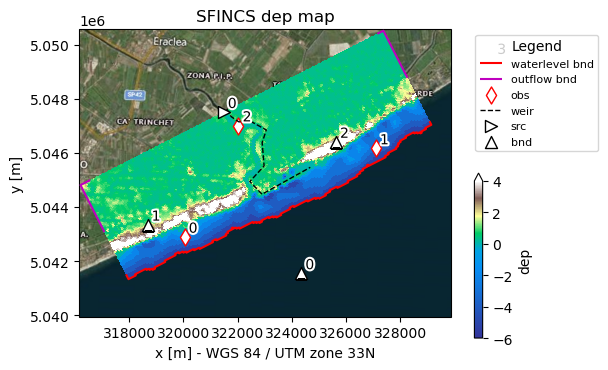

In [5]:
# Use predefined plotting function 'plot_basemap' to show your full SFINCS model setup
_ = sf.plot_basemap(
    fn_out="basemap.png",
    variable="dep",
    plot_geoms=True,
    plot_bounds=True,
    bmap="sat",
    zoomlevel=12,
)

### 5. Save all files

In [5]:
sf.write()  # write all

2025-11-22 17:44:36,677 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - INFO - No subgrid table available to write.


<div style="border-left: 4px solid #4CAF50; padding: 0.5em; background-color: #f0fff0;">
<b>⚠️ Note:</b> If you encounter a <code>PermissionError</code> when writing the model,
it's likely because another notebook or process currently has the NetCDF files with boundary conditions open.
This can happen when multiple Jupyter kernels access the same <code>.nc</code> file simultaneously.<br><br>
👉 <b>To resolve it:</b><br>
&nbsp;&nbsp;• Save your work in other notebooks using this file.<br>
&nbsp;&nbsp;• Restart or close those kernels.<br>
&nbsp;&nbsp;• Then rerun this notebook.
</div>



<div style="border-left: 4px solid #2196F3; padding: 0.5em; background-color: #e7f3fe;">
<b>💡 Note:</b> GIS files are written for your geometries into the <code>gis</code> subfolder
in the model root. These files are not used by the SFINCS model, but can be handy
when visualizing the model in QGIS or ArcGIS.
</div>


Now you have made an update model, you can progress to the notebook: [Run SFINCS Model](4_run_model.ipynb).